# 📊 Custom Churn Analysis | Advanced EDA Project

## 🎯 Objective
The objective of this project is to analyze customer churn behavior,
identify high-risk customer segments, calculate churn KPIs,
and provide data-driven retention strategies.

## 🛠 Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# 📦  Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# 📥  Load Dataset

In [24]:
df = pd.read_csv("customer_churn.csv")

df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


## 📌 Dataset Overview
Let’s understand structure, missing values and datatypes.

In [29]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


# 🧹  Data Cleaning

- Remove extra spaces in column names
- Convert TotalCharges to numeric
- Handle missing values

In [38]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

# 📊  Basic KPI Analysis

### 📌  Overall Churn Rate

In [47]:
churn_rate = df['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 14.49%


### 🟢  Churn Distribution

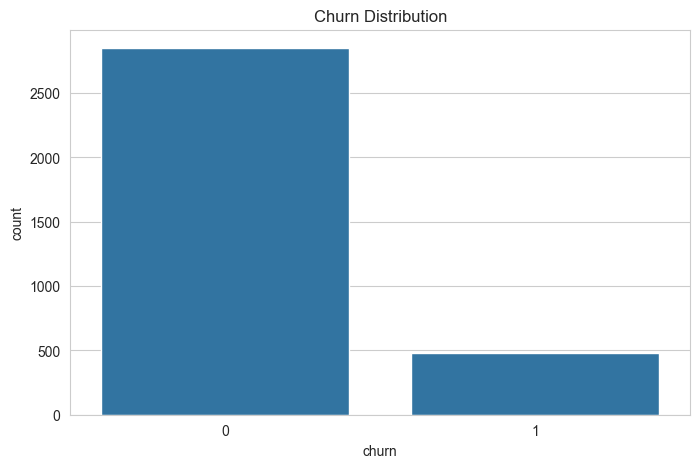

In [50]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

# 🟢  Behavioral Analysis

### 📌 Contract Renewal Impact

In [53]:
pd.crosstab(df['contractrenewal'], df['churn'], normalize='index') * 100

churn,0,1
contractrenewal,,
0,57.585139,42.414861
1,88.504983,11.495017


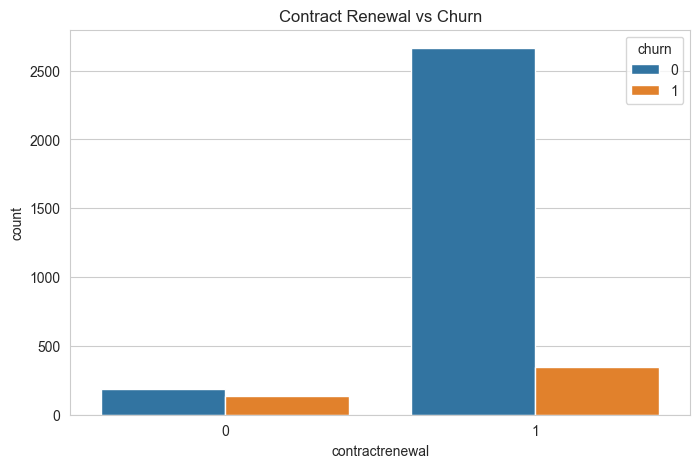

In [55]:
sns.countplot(x='contractrenewal', hue='churn', data=df)
plt.title("Contract Renewal vs Churn")
plt.show()

### 📌 Customer Service Calls Impact

In [59]:
df.groupby('churn')['custservcalls'].mean()

churn
0    1.449825
1    2.229814
Name: custservcalls, dtype: float64

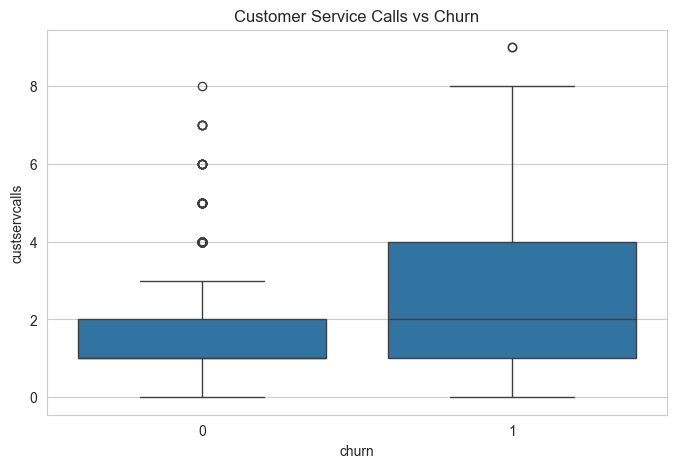

In [61]:
sns.boxplot(x='churn', y='custservcalls', data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

### 📌  Monthly Charge Analysis

In [64]:
df.groupby('churn')['monthlycharge'].mean()

churn
0    55.816246
1    59.190062
Name: monthlycharge, dtype: float64

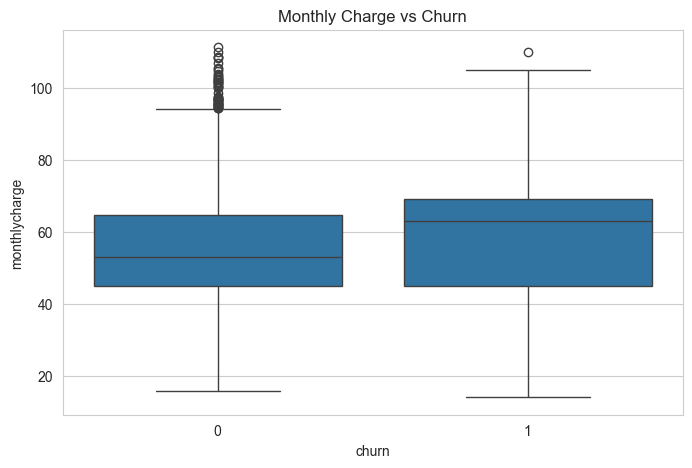

In [66]:
sns.boxplot(x='churn', y='monthlycharge', data=df)
plt.title("Monthly Charge vs Churn")
plt.show()

### 📌 Usage Pattern Analysis

In [69]:
df.groupby('churn')[['daymins','roammins','datausage']].mean()

,daymins,roammins,datausage
churn,,,
0,175.175754,10.158877,0.862151
1,206.914079,10.700000,0.546957


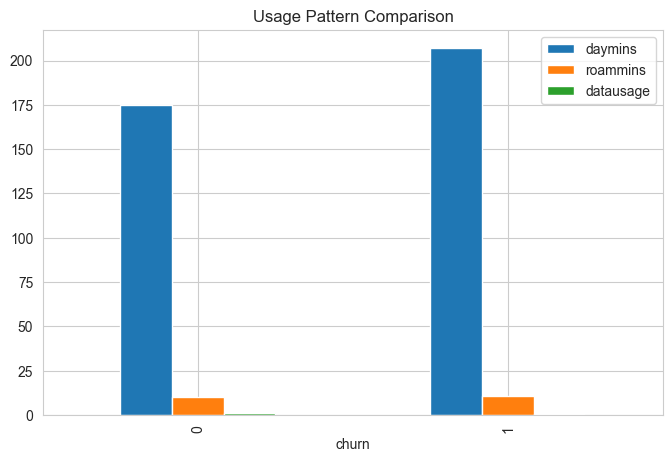

In [71]:
df.groupby('churn')[['daymins','roammins','datausage']].mean().plot(kind='bar')
plt.title("Usage Pattern Comparison")
plt.show()

# 🟢 Correlation Analysis

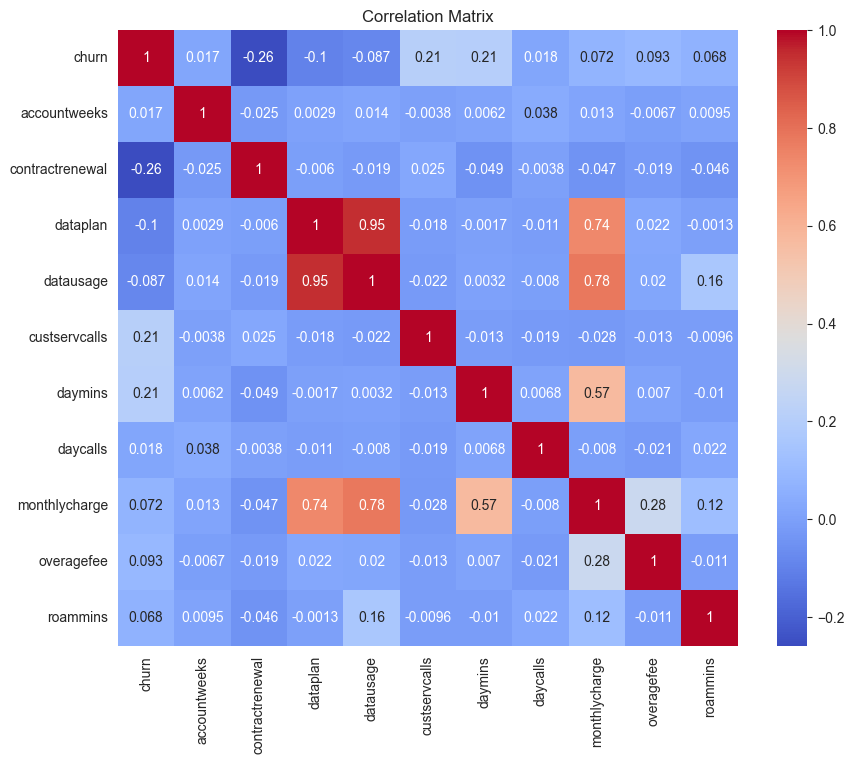

In [74]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Identify:

    * Strong positive correlations

    * Variables strongly correlated with churn

# 🟢  Customer Segmentation

In [78]:
df['risk_segment'] = np.where(
    (df['custservcalls'] > 3) & (df['monthlycharge'] > 70),
    "High Risk",
    "Low Risk"
)

pd.crosstab(df['risk_segment'], df['churn'], normalize='index') * 100

churn,0,1
risk_segment,,
High Risk,70.909091,29.090909
Low Risk,85.753508,14.246492


# 🟢  Final Business Insights

# 📌 Key Findings

1. Customers without contract renewal have significantly higher churn.
2. High customer service calls strongly correlate with churn.
3. Higher monthly charges increase churn probability.
4. Heavy roaming and day usage customers show higher churn tendency.

# 💡 Business Recommendations

• Improve customer service response time  
• Provide loyalty discounts for high-bill customers  
• Encourage long-term contract renewals  
• Monitor high complaint customers proactively  